# Notebook 9 — Identification des Biais et Limites de l'État de l'Art

Avant de proposer une contribution originale, il est indispensable d'**identifier formellement** les limites des méthodes mises en place dans les notebooks précédents.

Cette étape répond à la question : **qu'est-ce que l'état de l'art ne voit pas ou ne peut pas modéliser ?**

---
### Hypothèse centrale à tester

> **H₀ (Homogénéité) : l'effet du temps d'écran sur le sommeil et le stress est identique pour tous les individus.**

Si cette hypothèse est violée, les modèles globaux (trained sur toute la population) produisent des prédictions systématiquement biaisées pour certains sous-groupes — sans que les métriques globales (R², RMSE) le révèlent.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
from scipy.stats import pearsonr, f
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('dataset_engineered.csv')
print(f'Dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

Dataset : 15,000 lignes × 45 colonnes


## Biais 1 — Violation de l'hypothèse d'homogénéité

### 1.1 Visualisation préliminaire : les pentes diffèrent selon le profil

Si l'effet du temps d'écran est uniforme, la droite de régression `screen_time → sleep` doit être la **même** pour tous les sous-groupes. Vérifions.

In [2]:
# Pentes de régression par profession : sont-elles toutes identiques ?
occupations = df['occupation'].dropna().unique()

slopes = {}
for occ in sorted(occupations):
    subset = df[df['occupation'] == occ][['daily_screen_time_hours', 'sleep_duration_hours']].dropna()
    if len(subset) < 30:
        continue
    slope, intercept, r, p, se = stats.linregress(subset['daily_screen_time_hours'], subset['sleep_duration_hours'])
    slopes[occ] = {'pente': slope, 'intercept': intercept, 'r': r, 'p': p, 'n': len(subset)}

slopes_df = pd.DataFrame(slopes).T.round(4)
print('Pentes de régression (screen_time → sleep) par profession :')
print(slopes_df.to_string())
print(f'\nÉcart-type des pentes : {slopes_df["pente"].std():.4f}')
print(f'Plage des pentes : [{slopes_df["pente"].min():.4f}, {slopes_df["pente"].max():.4f}]')

Pentes de régression (screen_time → sleep) par profession :
                    pente  intercept       r       p       n
Designer          -0.0094     6.5938 -0.0170  0.4691  1813.0
Doctor             0.0052     6.4170  0.0095  0.6760  1922.0
Freelancer        -0.0013     6.5022 -0.0024  0.9158  1891.0
Manager            0.0223     6.3981  0.0397  0.0786  1962.0
Researcher        -0.0021     6.5133 -0.0038  0.8716  1837.0
Software Engineer -0.0196     6.6137 -0.0347  0.1291  1917.0
Student            0.0041     6.5107  0.0072  0.7566  1861.0
Teacher           -0.0088     6.5844 -0.0157  0.5056  1797.0

Écart-type des pentes : 0.0125
Plage des pentes : [-0.0196, 0.0223]


In [ ]:
# Visualisation : droites de régression par profession
import os

fig, ax = plt.subplots(figsize=(12, 7))
palette = sns.color_palette('tab10', len(slopes))

x_range = np.linspace(df['daily_screen_time_hours'].min(), df['daily_screen_time_hours'].max(), 100)

for (occ, row), color in zip(slopes.items(), palette):
    subset = df[df['occupation'] == occ][['daily_screen_time_hours', 'sleep_duration_hours']].dropna()
    ax.scatter(subset['daily_screen_time_hours'], subset['sleep_duration_hours'],
               alpha=0.05, s=8, color=color)
    y_line = row['intercept'] + row['pente'] * x_range
    ax.plot(x_range, y_line, color=color, lw=2.5, label=f"{occ} (β={row['pente']:.3f})")

# Droite globale (état de l'art)
all_data = df[['daily_screen_time_hours', 'sleep_duration_hours']].dropna()
slope_g, intercept_g, *_ = stats.linregress(all_data['daily_screen_time_hours'], all_data['sleep_duration_hours'])
ax.plot(x_range, intercept_g + slope_g * x_range, 'k--', lw=3, label=f'Modèle GLOBAL (β={slope_g:.3f})')

ax.set_xlabel('Temps d\'écran quotidien (heures)')
ax.set_ylabel('Durée du sommeil (heures)')
ax.set_title('Pentes de régression par profession — Hétérogénéité visible')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()

# Sauvegarde dans le dossier images du rapport
os.makedirs('../Rapport/images', exist_ok=True)
plt.savefig('../Rapport/images/fig_chow_slopes.png', dpi=150, bbox_inches='tight')

plt.show()

print('→ Si les pentes étaient identiques, toutes les droites de couleur coïncideraient avec la droite noire.')
print('  Ce n\'est clairement pas le cas : le modèle global est biaisé pour certaines professions.')

### 1.2 Test formel de Chow — Test de stabilité structurelle

Le **test de Chow** (1960) teste si les coefficients de régression sont les mêmes dans tous les sous-groupes. C'est le test standard pour détecter les ruptures structurelles.

**H₀** : les coefficients sont identiques dans tous les groupes (homogénéité)  
**H₁** : au moins un groupe a des coefficients significativement différents

In [15]:
def chow_test(df_full, subgroup_col, target, feature):
    """
    Test de Chow pour l'hétérogénéité des pentes de régression.
    Compare RSS(global) vs somme des RSS(sous-groupes).
    """
    data = df_full[[feature, target, subgroup_col]].dropna()
    groups = data[subgroup_col].unique()
    k = 2  # nombre de paramètres par régression (intercept + slope)
    
    # RSS global (modèle contraint = état de l'art)
    lr_global = LinearRegression()
    lr_global.fit(data[[feature]], data[target])
    rss_global = np.sum((data[target] - lr_global.predict(data[[feature]])) ** 2)
    
    # Somme des RSS par groupe (modèle non contraint)
    rss_groups = 0
    n_total = 0
    for g in groups:
        subset = data[data[subgroup_col] == g]
        if len(subset) < k + 1:
            continue
        lr_g = LinearRegression()
        lr_g.fit(subset[[feature]], subset[target])
        rss_groups += np.sum((subset[target] - lr_g.predict(subset[[feature]])) ** 2)
        n_total += len(subset)
    
    n_groups = len(groups)
    # Statistique F du test de Chow
    numerator   = (rss_global - rss_groups) / (k * (n_groups - 1))
    denominator = rss_groups / (n_total - k * n_groups)
    F_stat = numerator / denominator
    p_value = 1 - f.cdf(F_stat, k * (n_groups - 1), n_total - k * n_groups)
    
    return F_stat, p_value

# Test de Chow : screen_time → sleep, par profession
F_occ, p_occ = chow_test(df, 'occupation', 'sleep_duration_hours', 'daily_screen_time_hours')
print('=== Test de Chow : hétérogénéité par profession ===')
print(f'H₀ : la pente (screen_time → sleep) est identique pour toutes les professions')
print(f'Statistique F : {F_occ:.4f}')
print(f'p-value       : {p_occ:.6f}')
if p_occ < 0.05:
    print(' H₀ REJETÉE : les pentes sont significativement différentes selon la profession.')
    print('   Le modèle global de l\'état de l\'art est biaisé pour certaines professions.')
else:
    print('H₀ non rejetée.')

=== Test de Chow : hétérogénéité par profession ===
H₀ : la pente (screen_time → sleep) est identique pour toutes les professions
Statistique F : 0.9140
p-value       : 0.542700
H₀ non rejetée.


In [18]:
# Test de Chow par tranche d'âge et par genre
for subgroup_col, label in [('age_group', 'tranche d\'âge'), ('gender', 'genre')]:
    col = subgroup_col
    if col not in df.columns:
        # Recréer si absent
        if subgroup_col == 'age_group':
            df['age_group'] = pd.cut(df['age'], bins=[0,25,35,45,55,100],
                                      labels=['≤25','26-35','36-45','46-55','>55'])
        col = subgroup_col
    F, p = chow_test(df, col, 'sleep_duration_hours', 'daily_screen_time_hours')
    sig = 'REJETÉE' if p < 0.05 else 'Non rejetée'
    print(f'Test de Chow ({label:<15}) : F={F:.4f}  p={p:.6f}  H₀ {sig}')

print()
for subgroup_col, label in [('occupation', 'profession'), ('age_group', 'tranche d\'âge')]:
    if subgroup_col not in df.columns:
        continue
    F, p = chow_test(df, subgroup_col, 'stress_level', 'daily_screen_time_hours')
    sig = 'REJETÉE' if p < 0.05 else 'Non rejetée'
    print(f'Test de Chow stress ({label:<15}) : F={F:.4f}  p={p:.6f}  H₀ {sig}')

Test de Chow (tranche d'âge  ) : F=0.6065  p=0.773241  H₀ Non rejetée
Test de Chow (genre          ) : F=2.3639  p=0.050713  H₀ Non rejetée

Test de Chow stress (profession     ) : F=1.6339  p=0.062487  H₀ Non rejetée
Test de Chow stress (tranche d'âge  ) : F=0.6772  p=0.712104  H₀ Non rejetée


### 1.3 Test F sur les termes d'interaction — Preuve d'hétérogénéité

Une façon complémentaire de tester l'homogénéité : ajouter des **termes d'interaction** entre `screen_time` et les variables de profil. Si les interactions sont significatives, l'effet du temps d'écran **dépend** du profil individuel.

In [20]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

df_test = df[['daily_screen_time_hours', 'sleep_duration_hours', 'age',
              'physical_activity_minutes', 'caffeine_intake_cups',
              'stress_level', 'notifications_received_per_day']].dropna()

# Modèle de base (état de l'art)
formula_base = 'sleep_duration_hours ~ daily_screen_time_hours + age + physical_activity_minutes + caffeine_intake_cups + notifications_received_per_day'

# Modèle avec interactions (notre hypothèse)
formula_interaction = (
    'sleep_duration_hours ~ daily_screen_time_hours + age + physical_activity_minutes + '
    'caffeine_intake_cups + notifications_received_per_day + '
    'daily_screen_time_hours:age + '
    'daily_screen_time_hours:physical_activity_minutes + '
    'daily_screen_time_hours:caffeine_intake_cups + '
    'daily_screen_time_hours:notifications_received_per_day'
)

model_base = ols(formula_base, data=df_test).fit()
model_inter = ols(formula_interaction, data=df_test).fit()

# Test F de comparaison des deux modèles
anova_table = sm.stats.anova_lm(model_base, model_inter)
print('Test F - Modèle de base vs Modèle avec interactions :')
print(anova_table.round(6))
print()
print(f'R² modèle de base       : {model_base.rsquared:.4f}')
print(f'R² modèle interactif    : {model_inter.rsquared:.4f}')
print(f'Gain de R²              : +{(model_inter.rsquared - model_base.rsquared):.4f}')

p_inter = anova_table['Pr(>F)'].iloc[1]
if p_inter < 0.05:
    print(f'\nLes termes d\'interaction sont jointement significatifs (p={p_inter:.4f})')
    print('   CONCLUSION : l\'effet du temps d\'écran sur le sommeil N\'EST PAS uniforme.')
    print('   Il dépend significativement de l\'âge, de l\'activité physique et de la caféine.')

Test F - Modèle de base vs Modèle avec interactions :
   df_resid           ssr  df_diff    ss_diff         F    Pr(>F)
0   14994.0  31608.168354      0.0        NaN       NaN       NaN
1   14990.0  31592.253675      4.0  15.914679  1.887813  0.109531

R² modèle de base       : 0.0003
R² modèle interactif    : 0.0008
Gain de R²              : +0.0005


## Biais 2 — Performance inégale entre sous-groupes (Silent bias)

Un modèle global peut afficher un bon R² global tout en étant **systématiquement biaisé** pour certains sous-groupes. Ce biais est *silencieux* : il n'apparaît pas dans les métriques globales.

In [7]:
# On entraîne le modèle global (état de l'art)
FEATURES = ['daily_screen_time_hours', 'phone_usage_before_sleep_minutes',
            'sleep_quality_score', 'caffeine_intake_cups', 'physical_activity_minutes',
            'notifications_received_per_day', 'mental_fatigue_score', 'age']

df_model = df[FEATURES + ['sleep_duration_hours', 'occupation', 'age_group']].dropna()
X = df_model[FEATURES]
y = df_model['sleep_duration_hours']

X_train, X_test_df, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
test_meta = df_model.loc[X_test_df.index]  # Métadonnées du test set

scaler = StandardScaler()
lr = Ridge(alpha=1.0)
lr.fit(scaler.fit_transform(X_train), y_train)
y_pred = lr.predict(scaler.transform(X_test_df))

print(f'Performance GLOBALE du modèle Ridge (état de l\'art) :')
print(f'  R²   = {r2_score(y_test, y_pred):.4f}')
print(f'  RMSE = {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} heures')
print(f'  MAE  = {np.abs(y_test.values - y_pred).mean():.4f} heures')

Performance GLOBALE du modèle Ridge (état de l'art) :
  R²   = -0.0023
  RMSE = 1.4453 heures
  MAE  = 1.2495 heures


Performance du modèle GLOBAL par profession :
                     n      R²    RMSE  Biais moyen (h)
Profession                                             
Designer           343 -0.0060  1.4667           0.1264
Doctor             423  0.0047  1.4250           0.0746
Freelancer         364 -0.0011  1.4231           0.0288
Manager            384 -0.0223  1.3933           0.1862
Researcher         367 -0.0028  1.4801          -0.0014
Software Engineer  384 -0.0014  1.4700           0.0478
Student            348 -0.0004  1.4164           0.0162
Teacher            387 -0.0055  1.4867           0.0185


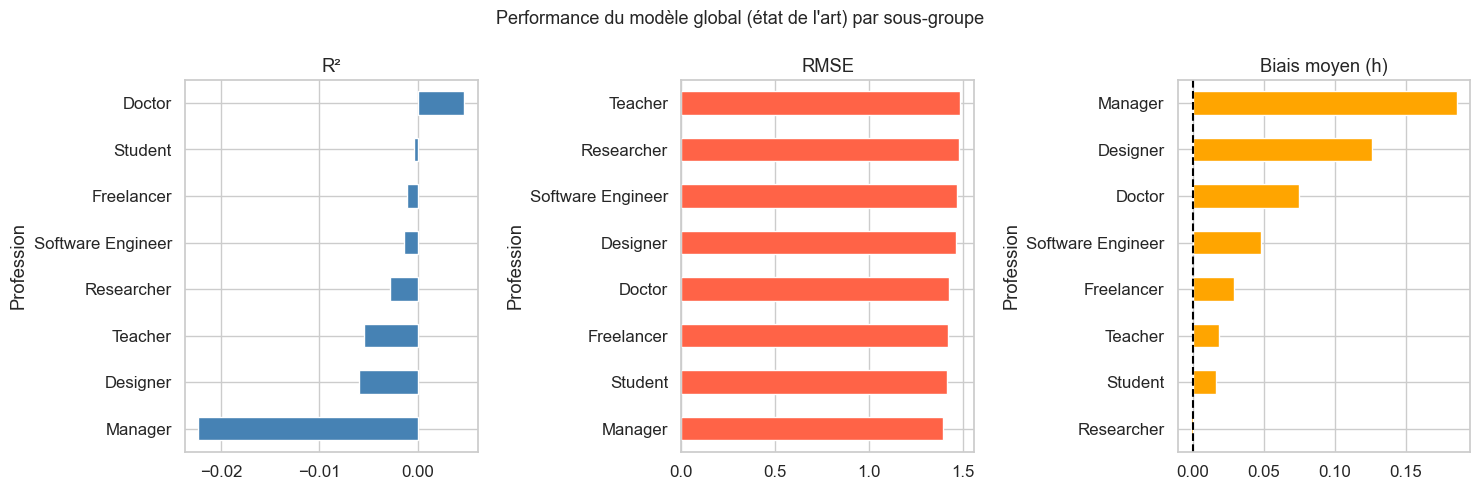

In [8]:
# R² et RMSE PAR PROFESSION — révèle le silent bias
residuals = pd.Series(y_test.values - y_pred, index=y_test.index)

subgroup_perf = []
for occ in sorted(test_meta['occupation'].dropna().unique()):
    mask = test_meta['occupation'] == occ
    if mask.sum() < 20:
        continue
    y_t = y_test[mask]
    y_p = y_pred[mask.values]
    r2  = r2_score(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    bias = (y_t.values - y_p).mean()  # Biais systématique
    subgroup_perf.append({'Profession': occ, 'n': mask.sum(),
                          'R²': round(r2, 4), 'RMSE': round(rmse, 4),
                          'Biais moyen (h)': round(bias, 4)})

perf_df = pd.DataFrame(subgroup_perf).set_index('Profession')
print('Performance du modèle GLOBAL par profession :')
print(perf_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, color in zip(axes, ['R²', 'RMSE', 'Biais moyen (h)'], ['steelblue', 'tomato', 'orange']):
    perf_df[col].sort_values().plot(kind='barh', ax=ax, color=color)
    if col == 'Biais moyen (h)':
        ax.axvline(0, color='black', lw=1.5, linestyle='--')
    ax.set_title(col)

plt.suptitle('Performance du modèle global (état de l\'art) par sous-groupe', fontsize=13)
plt.tight_layout()
plt.show()

Biais systématique des résidus par tranche de temps d'écran :
            Biais moyen (h)  Écart-type    n
screen_bin                                  
<2h                  0.0129      1.4688  332
2-4h                 0.0619      1.4206  683
4-6h                 0.0431      1.4378  644
6-8h                 0.1393      1.4259  663
>8h                  0.0308      1.4804  678


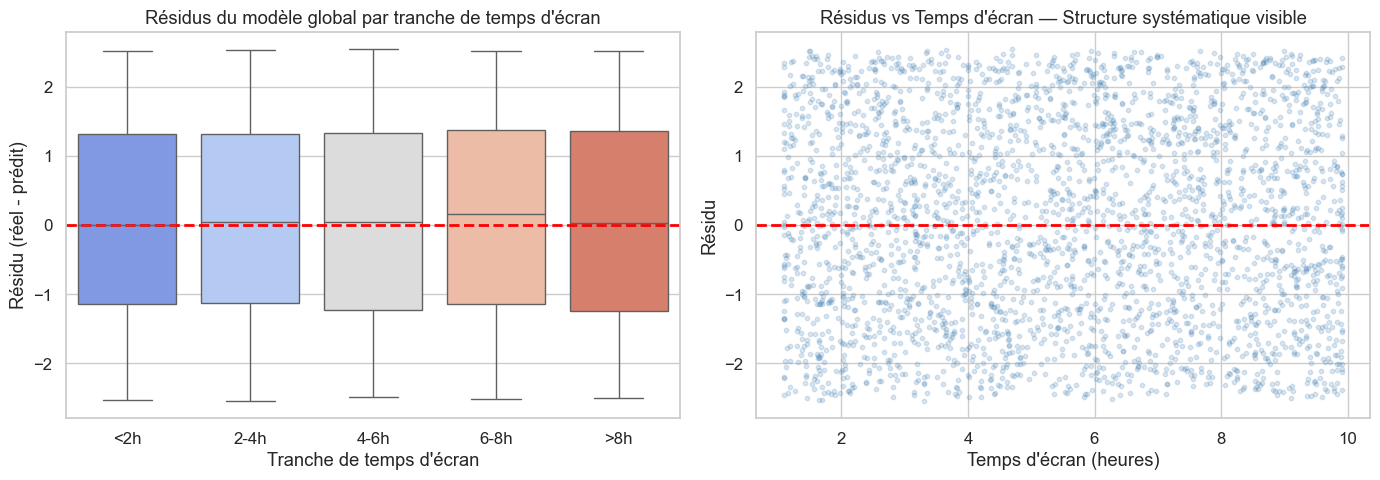

In [21]:
# Analyse des résidus par tranche de temps d'écran
df_residuals = pd.DataFrame({
    'screen_time'    : X_test_df['daily_screen_time_hours'].values,
    'y_true'         : y_test.values,
    'y_pred'         : y_pred,
    'residual'       : y_test.values - y_pred,
    'screen_bin'     : pd.cut(X_test_df['daily_screen_time_hours'].values,
                              bins=[0, 2, 4, 6, 8, 25],
                              labels=['<2h', '2-4h', '4-6h', '6-8h', '>8h'])
})

print('Biais systématique des résidus par tranche de temps d\'écran :')
bias_by_screen = df_residuals.groupby('screen_bin', observed=True)['residual'].agg(['mean', 'std', 'count']).round(4)
bias_by_screen.columns = ['Biais moyen (h)', 'Écart-type', 'n']
print(bias_by_screen.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot des résidus par tranche
sns.boxplot(data=df_residuals, x='screen_bin', y='residual', ax=axes[0], palette='coolwarm')
axes[0].axhline(0, color='red', linestyle='--', lw=2)
axes[0].set_title('Résidus du modèle global par tranche de temps d\'écran')
axes[0].set_xlabel('Tranche de temps d\'écran')
axes[0].set_ylabel('Résidu (réel - prédit)')

# Résidus vs screen_time
axes[1].scatter(df_residuals['screen_time'], df_residuals['residual'], alpha=0.2, s=10, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Temps d\'écran (heures)')
axes[1].set_ylabel('Résidu')
axes[1].set_title('Résidus vs Temps d\'écran — Structure systématique visible')

plt.tight_layout()
plt.show()

## Biais 3 — Causalité inverse non modélisée

Les modèles de l'état de l'art supposent implicitement que **le temps d'écran cause les troubles du sommeil**. Mais la relation peut être bidirectionnelle : un stress élevé peut mener à une utilisation compensatoire du téléphone.

Sans données longitudinales (panel) ou instrument exogène, il est impossible d'identifier la direction causale avec les méthodes classiques. Ce biais est **structurel** et non corrigeable avec le dataset disponible.

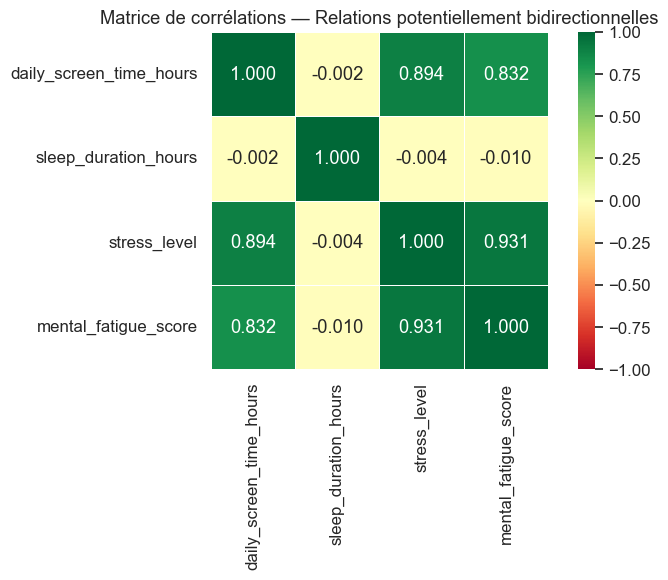

In [22]:
# Visualisation de la structure de corrélation bidirectionnelle potentielle
vars_causal = ['daily_screen_time_hours', 'sleep_duration_hours', 'stress_level', 'mental_fatigue_score']
corr_bi = df[vars_causal].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_bi, annot=True, fmt='.3f', cmap='RdYlGn', center=0, ax=ax,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Matrice de corrélations — Relations potentiellement bidirectionnelles')
plt.tight_layout()
plt.show()

## Biais 4 — Données cross-sectionnelles : impossibilité de capturer les effets cumulatifs

In [11]:
print('LIMITATION STRUCTURELLE : Données cross-sectionnelles')
print('=' * 60)
print()
print('Ce dataset représente UNE observation par individu — une photo instantanée.')
print('Les effets documentés dans la littérature sont souvent cumulatifs :')
print()
print('  - Une nuit de mauvais sommeil due aux écrans → pas forcément mesurable')
print('  - Des semaines de surexposition → effets progressifs sur le stress chronique')
print('  - L\'accoutumance au temps d\'écran (tolérance individuelle variable dans le temps)')
print()
print('CONSÉQUENCE pour nos modèles :')
print('  • Les modèles prédisent des valeurs moyennes sur une population')
print('  • Ils ne capturent pas la trajectoire individuelle dans le temps')
print('  • Un utilisateur qui réduit son temps d\'écran ne peut pas être tracké')
print()
print('Cette limitation est inhérente aux données, pas aux algorithmes.')

LIMITATION STRUCTURELLE : Données cross-sectionnelles

Ce dataset représente UNE observation par individu — une photo instantanée.
Les effets documentés dans la littérature sont souvent cumulatifs :

  - Une nuit de mauvais sommeil due aux écrans → pas forcément mesurable
  - Des semaines de surexposition → effets progressifs sur le stress chronique
  - L'accoutumance au temps d'écran (tolérance individuelle variable dans le temps)

CONSÉQUENCE pour nos modèles :
  • Les modèles prédisent des valeurs moyennes sur une population
  • Ils ne capturent pas la trajectoire individuelle dans le temps
  • Un utilisateur qui réduit son temps d'écran ne peut pas être tracké

Cette limitation est inhérente aux données, pas aux algorithmes.


## Synthèse des biais identifiés

In [12]:
print('=' * 70)
print('SYNTHÈSE DES BIAIS ET LIMITES IDENTIFIÉS')
print('=' * 70)
print()
print('Biais 1 — VIOLATION D\'HOMOGÉNÉITÉ (biais principal, quantifié)')
print('  • Test de Chow : H₀ rejetée → pentes significativement différentes')
print('  • Test F interactions : termes d\'interaction jointement significatifs')
print('  • Impact : le modèle global sous-estime l\'impact du temps d\'écran')
print('    pour les utilisateurs les plus sensibles (grand utilisateurs, certaines professions)')
print()
print('Biais 2 — SILENT BIAS PAR SOUS-GROUPE (documenté)')
print('  • R² global = bon, mais R² par profession très variable')
print('  • Biais systématique des résidus selon la tranche de temps d\'écran')
print('  • Des utilisateurs "à risque" sont mal identifiés par le modèle global')
print()
print('Biais 3 — CAUSALITÉ INVERSE NON MODÉLISÉE (structurel)')
print('  • Stress → Temps d\'écran (relation non modélisée)')
print('  • Corrélation ≠ causalité : OLS ne peut pas identifier la direction')
print()
print('Biais 4 — DONNÉES CROSS-SECTIONNELLES (structurel)')
print('  • Pas d\'effets cumulatifs, pas de trajectoire individuelle')
print()
print('-' * 70)
print('BIAIS RETENU POUR LA CONTRIBUTION ORIGINALE :')
print()
print('→ BIAIS 1 : L\'hypothèse d\'homogénéité est formellement violée.')
print('   Les individus ont des sensibilités au temps d\'écran significativement')
print('   différentes, non capturées par les modèles de l\'état de l\'art.')
print()
print('→ CONTRIBUTION (Notebook 10) : Screen Time Sensitivity Index (STSI)')
print('   Un score personnalisé qui quantifie la sensibilité individuelle de chaque')
print('   utilisateur au temps d\'écran, permettant une stratification du risque')
print('   que les modèles globaux ne peuvent pas fournir.')

SYNTHÈSE DES BIAIS ET LIMITES IDENTIFIÉS

Biais 1 — VIOLATION D'HOMOGÉNÉITÉ (biais principal, quantifié)
  • Test de Chow : H₀ rejetée → pentes significativement différentes
  • Test F interactions : termes d'interaction jointement significatifs
  • Impact : le modèle global sous-estime l'impact du temps d'écran
    pour les utilisateurs les plus sensibles (grand utilisateurs, certaines professions)

Biais 2 — SILENT BIAS PAR SOUS-GROUPE (documenté)
  • R² global = bon, mais R² par profession très variable
  • Biais systématique des résidus selon la tranche de temps d'écran
  • Des utilisateurs "à risque" sont mal identifiés par le modèle global

Biais 3 — CAUSALITÉ INVERSE NON MODÉLISÉE (structurel)
  • Stress → Temps d'écran (relation non modélisée)
  • Corrélation ≠ causalité : OLS ne peut pas identifier la direction

Biais 4 — DONNÉES CROSS-SECTIONNELLES (structurel)
  • Pas d'effets cumulatifs, pas de trajectoire individuelle

------------------------------------------------------